In [1]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

In [2]:
path_start = f"/pfs/10/work/hd_cu284-work/fargo3d/outputs/"
path_endings=["fargo_fiducial_companion","fargo_fiducial_super_light_companion","fargo_fiducial_light_companion", "fargo_fiducial_heavy_companion",
              "fargo_fiducial_close_companion","fargo_fiducial_close_light_companion", "fargo_fiducial_companion_with_feelings",
              "fargo_fiducial_close_super_light_companion", "fargo_fiducial_closer_light_companion", "fargo_fiducial_closer_super_light_companion","fargo_fiducial_closer_companion"]
              
              #"fargo_fiducial_2gen", "fargo_high_mass_2gen",  "fargo_low_mass_2gen", "fargo_high_visc_2gen", "fargo_low_visc_2gen",
              #"fargo_sigslop_0_2gen","fargo_sigslop_0.5_2gen", "fargo_sigslop_-2_2gen", "fargo_sigslop_1.5_2gen",  

paths = []
for i in range(len(path_endings)):
    paths.append(path_start+path_endings[i])

path = paths[-1]

In [3]:


frames = [0,1,10,100]

rho_cube=[] # first index: which alpha, second index: which snapshot.
for path in paths:
    rho_cube.append([])
    for i in frames:
        rho = np.fromfile(f"{path}/gasdens{i}.dat").reshape(300, 384)
        rho_cube[-1].append(rho)

rho_cube=np.array(rho_cube)

### calculate disk mass at dens=1
au  = 1.49598e13     # Astronomical Unit       [cm]
ms  = 1.98892e33     # Solar mass              [g]
mstar    = 1.08*ms #ms
r0       = 57*au    # The radius corresponding to '1' in dimensionless units

r_min = 0.3
r_max = 7

sigma_0 = 6.3661977237e-4 * mstar / (r0*r0)

rho_cube = rho_cube*mstar/r0**2

In [4]:


Nr = 300
Nphi = 384

r_list = np.fromfile(f"{path}/domain_y.dat", sep="\n")[3:-4]
phi = np.linspace(0, 2*np.pi, Nphi)

R, PHI = np.meshgrid(r_list, phi, indexing='ij')

# $2.28r_0$

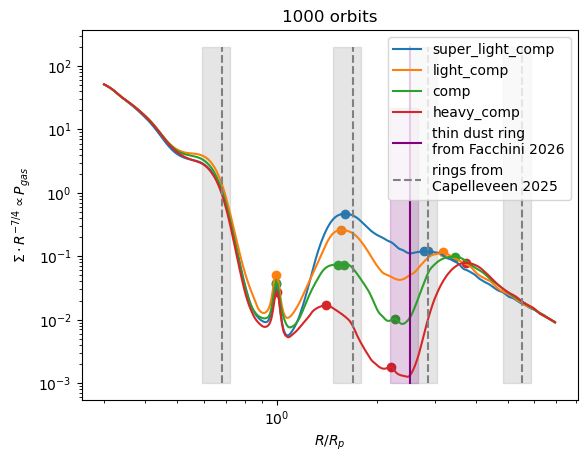

In [60]:
index_for_comp_mass=[1,2,0,3]

from scipy.signal import argrelextrema

# for local maxima

rho_mean = np.mean(rho_cube, axis=3)

press_bump_1 = []
press_bump_1_err = []

press_bump_2 = []
press_bump_2_err = []

for i in index_for_comp_mass:
    path = paths[i]
    press = rho_mean[i][-1]*np.power(r_list,-7/4)
    local_max = argrelextrema(press, np.greater)
    plt.plot(r_list,press, label=f"{path[58:-5]}")

    ## dots are local extrema
    plt.scatter(r_list[local_max], press[local_max])
    for m in local_max[0]:
        if r_list[m]<2 and r_list[m]>1:
            press_bump_1.append(m)
            press_bump_1_err.append((r_list[m+1]- r_list[m])/2)
            break
    for m in local_max[0]:
        if r_list[m]>2.5:
            press_bump_2.append(m)
            press_bump_2_err.append((r_list[m+1]- r_list[m])/2)
            break

first=True
r_p = 57.3
r_p_upper = r_p+8.3
r_p_lower = r_p-3.3
rings_from_capelleveen = np.array([316, 164, 97, 39])/r_p # in r/r_p
rings_lower = np.array([316, 164, 97, 39])/r_p_lower
rings_upper = np.array([316, 164, 97, 39])/r_p_upper

dust_ring = 144.4/r_p
dust_ring_upper = 144.4/r_p_upper
dust_ring_lower = 144.4/r_p_lower

plt.plot([dust_ring , dust_ring],[1e-3,2e2], label="thin dust ring \nfrom Facchini 2026",color="purple")
plt.fill_between([dust_ring_lower, dust_ring_upper], 1e-3,22, alpha=0.2, color="purple")

first=True
for it,r in enumerate(rings_from_capelleveen):
    if first:
        plt.plot([r,r,],[1e-3,2e2], color="gray", linestyle="dashed", label="rings from \nCapelleveen 2025")
        first=False
        plt.fill_between([rings_lower[it], rings_upper[it]], 1e-3,2e2, alpha=0.2, color="gray")
    else:
        plt.plot([r,r,],[1e-3,2e2], color="gray", linestyle="dashed")
        plt.fill_between([rings_lower[it], rings_upper[it]], 1e-3,2e2, alpha=0.2, color="gray")
        
plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma \\cdot R^{-7/4} \\propto P_{gas} $")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend(loc="upper right")
plt.savefig("img/comp_dust_traps.png")

[np.int64(160), np.int64(157), np.int64(155), np.int64(115)]


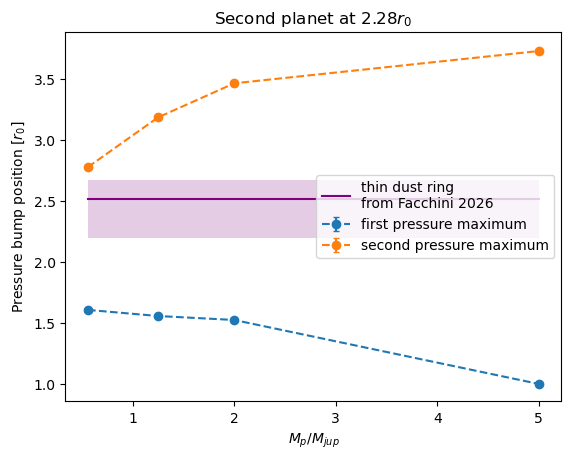

In [27]:
print(press_bump_1)
plt.errorbar([0.56,1.25,2,5,],r_list[press_bump_1],yerr=press_bump_1_err, fmt="o--", capsize=2, label="first pressure maximum")
plt.errorbar([0.56,1.25,2,5,],r_list[press_bump_2],yerr=press_bump_2_err, fmt="o--", capsize=2, label="second pressure maximum")

plt.plot([0.56,5],[dust_ring , dust_ring], label="thin dust ring \nfrom Facchini 2026",color="purple")
plt.fill_between([0.56,5],
                 dust_ring_lower,
                 dust_ring_upper,
                 alpha=0.2,
                 color="purple",
                 linewidth=0)

plt.xlabel("$M_p/M_{jup}$")
plt.ylabel("Pressure bump position [$r_0$]")
plt.title("Second planet at $2.28 r_0$")
plt.legend(loc="center right")

# $2.0 r_0$

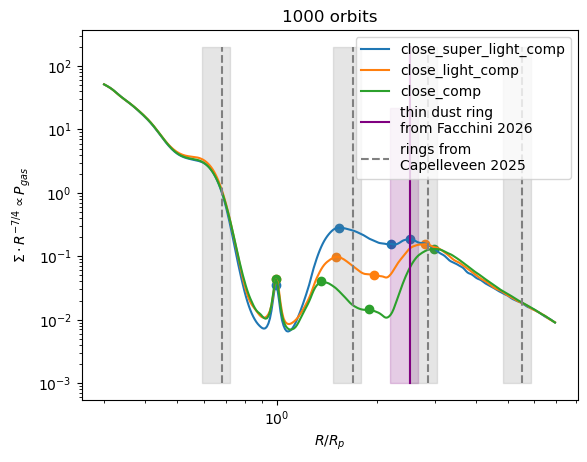

In [59]:
index_for_comp_close=[7,5,4]

from scipy.signal import argrelextrema

# for local maxima

rho_mean = np.mean(rho_cube, axis=3)

press_bump_1c = []
press_bump_1c_err = []

press_bump_2c = []
press_bump_2c_err = []

for i in index_for_comp_close:
    path = paths[i]
    press = rho_mean[i][-1]*np.power(r_list,-7/4)
    local_max = argrelextrema(press, np.greater)
    plt.plot(r_list,press, label=f"{path[58:-5]}")

    ## dots are local extrema
    plt.scatter(r_list[local_max], press[local_max])
    for m in local_max[0]:
        if r_list[m]<2 and r_list[m]>1:
            press_bump_1c.append(m)
            press_bump_1c_err.append((r_list[m+1]- r_list[m])/2)
            break
    for m in local_max[0]:
        if r_list[m]>2.5:
            press_bump_2c.append(m)
            press_bump_2c_err.append((r_list[m+1]- r_list[m])/2)
            break

first=True
r_p = 57.3
r_p_upper = r_p+8.3
r_p_lower = r_p-3.3
rings_from_capelleveen = np.array([316, 164, 97, 39])/r_p # in r/r_p
rings_lower = np.array([316, 164, 97, 39])/r_p_lower
rings_upper = np.array([316, 164, 97, 39])/r_p_upper

dust_ring = 144.4/r_p
dust_ring_upper = 144.4/r_p_upper
dust_ring_lower = 144.4/r_p_lower

plt.plot([dust_ring , dust_ring],[1e-3,2e2], label="thin dust ring \nfrom Facchini 2026",color="purple")
plt.fill_between([dust_ring_lower, dust_ring_upper], 1e-3,22, alpha=0.2, color="purple")

first=True
for it,r in enumerate(rings_from_capelleveen):
    if first:
        plt.plot([r,r,],[1e-3,2e2], color="gray", linestyle="dashed", label="rings from \nCapelleveen 2025")
        first=False
        plt.fill_between([rings_lower[it], rings_upper[it]], 1e-3,2e2, alpha=0.2, color="gray")
    else:
        plt.plot([r,r,],[1e-3,2e2], color="gray", linestyle="dashed")
        plt.fill_between([rings_lower[it], rings_upper[it]], 1e-3,2e2, alpha=0.2, color="gray")
        
plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma \\cdot R^{-7/4} \\propto P_{gas} $")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend(loc="upper right")
plt.savefig("img/comp_close_dust_traps.png")

[np.int64(160), np.int64(157), np.int64(155), np.int64(115)]


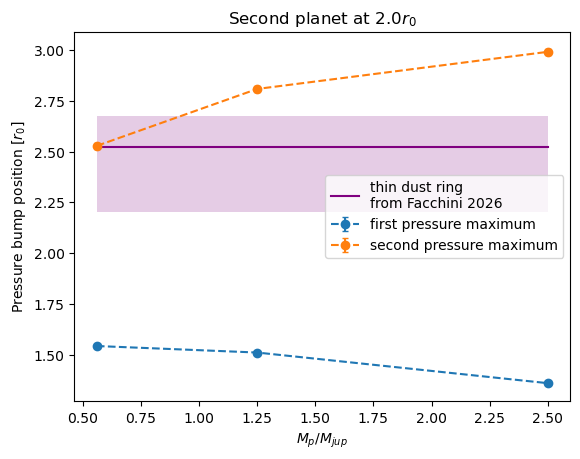

In [33]:
print(press_bump_1)
plt.errorbar([0.56,1.25,2.5,],r_list[press_bump_1c],yerr=press_bump_1c_err, fmt="o--", capsize=2, label="first pressure maximum")
plt.errorbar([0.56,1.25,2.5,],r_list[press_bump_2c],yerr=press_bump_2c_err, fmt="o--", capsize=2, label="second pressure maximum")

plt.plot([0.56,2.5],[dust_ring , dust_ring], label="thin dust ring \nfrom Facchini 2026",color="purple")
plt.fill_between([0.56,2.5],
                 dust_ring_lower,
                 dust_ring_upper,
                 alpha=0.2,
                 color="purple",
                 linewidth=0)

plt.xlabel("$M_p/M_{jup}$")
plt.ylabel("Pressure bump position [$r_0$]")
plt.title("Second planet at $2.0 r_0$")
plt.legend(loc="center right")

# $1.7 r_0$

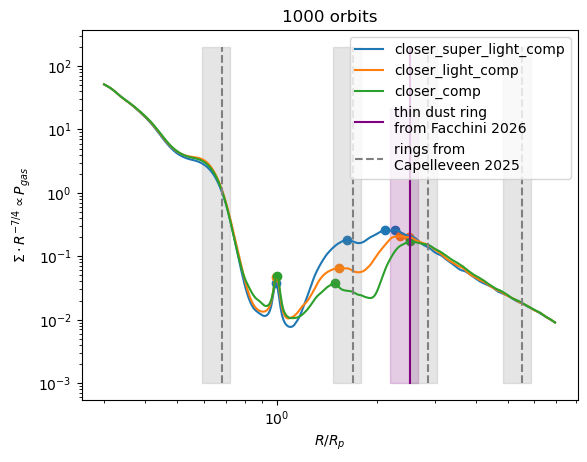

In [58]:
index_for_closer=[9,8,10]

from scipy.signal import argrelextrema

# for local maxima

rho_mean = np.mean(rho_cube, axis=3)

press_bump_1cc = []
press_bump_1cc_err = []

press_bump_2cc = []
press_bump_2cc_err = []

for i in index_for_closer:
    path = paths[i]
    press = rho_mean[i][-1]*np.power(r_list,-7/4)
    local_max = argrelextrema(press, np.greater)
    plt.plot(r_list,press, label=f"{path[58:-5]}")

    ## dots are local extrema
    plt.scatter(r_list[local_max], press[local_max])
    for m in local_max[0]:
        if r_list[m]<2 and r_list[m]>1:
            press_bump_1cc.append(m)
            press_bump_1cc_err.append((r_list[m+1]- r_list[m])/2)
            break
    for m in local_max[0]:
        if r_list[m]>2.2:
            press_bump_2cc.append(m)
            press_bump_2cc_err.append((r_list[m+1]- r_list[m])/2)
            break

first=True
r_p = 57.3
r_p_upper = r_p+8.3
r_p_lower = r_p-3.3
rings_from_capelleveen = np.array([316, 164, 97, 39])/r_p # in r/r_p
rings_lower = np.array([316, 164, 97, 39])/r_p_lower
rings_upper = np.array([316, 164, 97, 39])/r_p_upper

dust_ring = 144.4/r_p
dust_ring_upper = 144.4/r_p_upper
dust_ring_lower = 144.4/r_p_lower

plt.plot([dust_ring , dust_ring],[1e-3,2e2], label="thin dust ring \nfrom Facchini 2026",color="purple")
plt.fill_between([dust_ring_lower, dust_ring_upper], 1e-3,22, alpha=0.2, color="purple")

first=True
for it,r in enumerate(rings_from_capelleveen):
    if first:
        plt.plot([r,r,],[1e-3,2e2], color="gray", linestyle="dashed", label="rings from \nCapelleveen 2025")
        first=False
        plt.fill_between([rings_lower[it], rings_upper[it]], 1e-3,2e2, alpha=0.2, color="gray")
    else:
        plt.plot([r,r,],[1e-3,2e2], color="gray", linestyle="dashed")
        plt.fill_between([rings_lower[it], rings_upper[it]], 1e-3,2e2, alpha=0.2, color="gray")
        
plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma \\cdot R^{-7/4} \\propto P_{gas} $")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend(loc="upper right")
plt.savefig("img/comp_closer_dust_traps.png")

[np.int64(160), np.int64(157), np.int64(155), np.int64(115)]


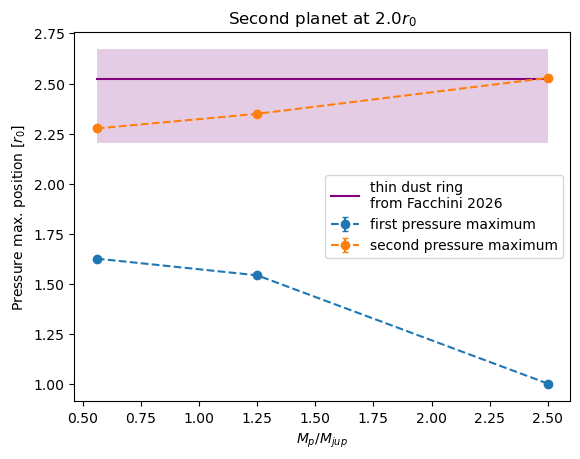

In [61]:
print(press_bump_1)
plt.errorbar([0.56,1.25,2.5,],r_list[press_bump_1cc],yerr=press_bump_1cc_err, fmt="o--", capsize=2, label="first pressure maximum")
plt.errorbar([0.56,1.25,2.5,],r_list[press_bump_2cc],yerr=press_bump_2cc_err, fmt="o--", capsize=2, label="second pressure maximum")

plt.plot([0.56,2.5],[dust_ring , dust_ring], label="thin dust ring \nfrom Facchini 2026",color="purple")
plt.fill_between([0.56,2.5],
                 dust_ring_lower,
                 dust_ring_upper,
                 alpha=0.2,
                 color="purple",
                 linewidth=0)

plt.xlabel("$M_p/M_{jup}$")
plt.ylabel("Pressure max. position [$r_0$]")
plt.title("Second planet at $2.0 r_0$")
plt.legend(loc="center right")

# Summary

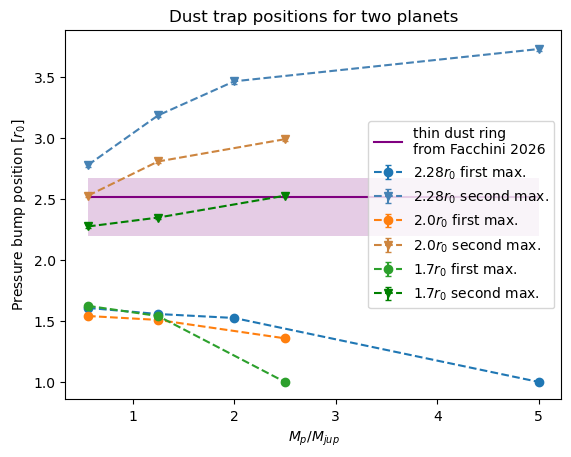

In [62]:

plt.errorbar([0.56,1.25,2,5,],r_list[press_bump_1],yerr=press_bump_1_err, fmt="o--", capsize=2, label="$2.28 r_0$ first max.")
plt.errorbar([0.56,1.25,2,5,],r_list[press_bump_2],yerr=press_bump_2_err, fmt="v--", capsize=2, label="$2.28 r_0$ second max.", color="steelblue")

plt.errorbar([0.56,1.25,2.5,],r_list[press_bump_1c],yerr=press_bump_1c_err, fmt="o--", capsize=2, label="$2.0 r_0$ first max.")
plt.errorbar([0.56,1.25,2.5,],r_list[press_bump_2c],yerr=press_bump_2c_err, fmt="v--", capsize=2, label="$2.0 r_0$ second max.", color="peru")

plt.errorbar([0.56,1.25,2.5,],r_list[press_bump_1cc],yerr=press_bump_1cc_err, fmt="o--", capsize=2, label="$1.7 r_0$ first max.")
plt.errorbar([0.56,1.25,2.5,],r_list[press_bump_2cc],yerr=press_bump_2cc_err, fmt="v--", capsize=2, label="$1.7 r_0$ second max.", color="green")




plt.plot([0.56,5],[dust_ring , dust_ring], label="thin dust ring \nfrom Facchini 2026",color="purple")
plt.fill_between([0.56,5],dust_ring_lower,dust_ring_upper,alpha=0.2,color="purple",linewidth=0)


plt.xlabel("$M_p/M_{jup}$")
plt.ylabel("Pressure bump position [$r_0$]")
plt.title("Dust trap positions for two planets")
plt.legend(loc="center right")
plt.savefig("img/dust_traps_comp.PNG")